In [2]:
import matplotlib.pyplot as plt
from KV_CACHE import KV_CACHE_GQA
import humanize

In [ ]:
#####Llama 4B Base --> CPU

#14 Tokens de Input // 1 Token Output
TtFT_CPU = [1.7920844000000216, 1.5263016999999763, 1.5218257999999878, 1.5380958999999166, 1.5348765999999614, 1.536232899999959, 1.5545011000001523, 1.5881632000000536, 1.7942344999999023, 1.7695811000000958, 1.7308573000000251, 1.7200886000000537, 1.7258646000000226, 1.7335607999998501, 1.734983100000136, 1.6029393000001164, 1.564358299999867, 1.5594427000000906, 1.5527870000000803, 1.5733338000000003, 1.552014900000131, 1.5499601999999868, 1.5824895000000652, 1.5702616999999464, 1.5492987000000085, 1.5469837000000553, 1.546567399999958, 1.555822600000056, 1.5821260000000166, 1.5697606999999607, 1.5425242999999682, 1.5750368999999864, 1.5775123000000804, 1.557877499999904, 1.5320438999999624]

#14 Tokens de Input // 100 Max_tokens output
Lat_CPU = [28.845445200000086, 30.20715549999977, 29.162379200000032, 29.513841799999682, 28.60348789999989, 28.970935499999996, 29.597843399999874, 28.55963470000006, 29.222640899999988, 29.1251771000002, 28.00827990000016, 28.10415779999994, 28.28073039999981, 28.206465299999763, 28.289368900000227] 

#14 Tokens de Input // 10 Max_tokens output
Throughput_CPU =  {
    'Prefill': [8.650445299999774, 1.775360499999806, 1.8060835999986011, 1.7644748999991862, 1.7817070000000967, 1.91291369999999, 1.7419178999989526, 1.7881133999999292, 1.763364400001592, 1.7523496000012528, 1.783080200000768, 1.8629350999999588, 1.7713653999999224], 
    'Decode': [442.6037436000006, 416.04662910000116, 407.14280510000026, 444.567560200001, 412.05906590000086, 415.4468992000002, 416.60171570000057, 420.4017975000006, 423.69321599999967, 426.84614330000113, 461.1847017, 411.4133648999996, 410.2796438999994, 408.4531982999997]
    }

#GB = Número de Parâmetros vs Bytes 
Bytes_Model = 8056505693


#KV Cache
QwenKV = {
    "Tamanho do Modelo": humanize.naturalsize (Bytes_Model),
}

for i in [1000, 7000, 13000, 20000, 26000, 32000]:
    x = KV_CACHE_GQA(36, i, 8, 128, 2)
    QwenKV[f"Tamanho do Modelo + {i} Tokens KV CACHE"] = humanize.naturalsize (Bytes_Model + x)

In [77]:
print (len(Throughput_CPU["Prefill"]) * 14 / sum(Throughput_CPU["Prefill"]))
print (len(Throughput_CPU["Decode"]) * 1500 / sum(Throughput_CPU["Decode"]))

print (len(Throughput_CPU["Prefill"]))
print (len(Throughput_CPU["Decode"]))

7.379112117405552
60.07822197317377
15
15


<h1> Tempo </h1> 

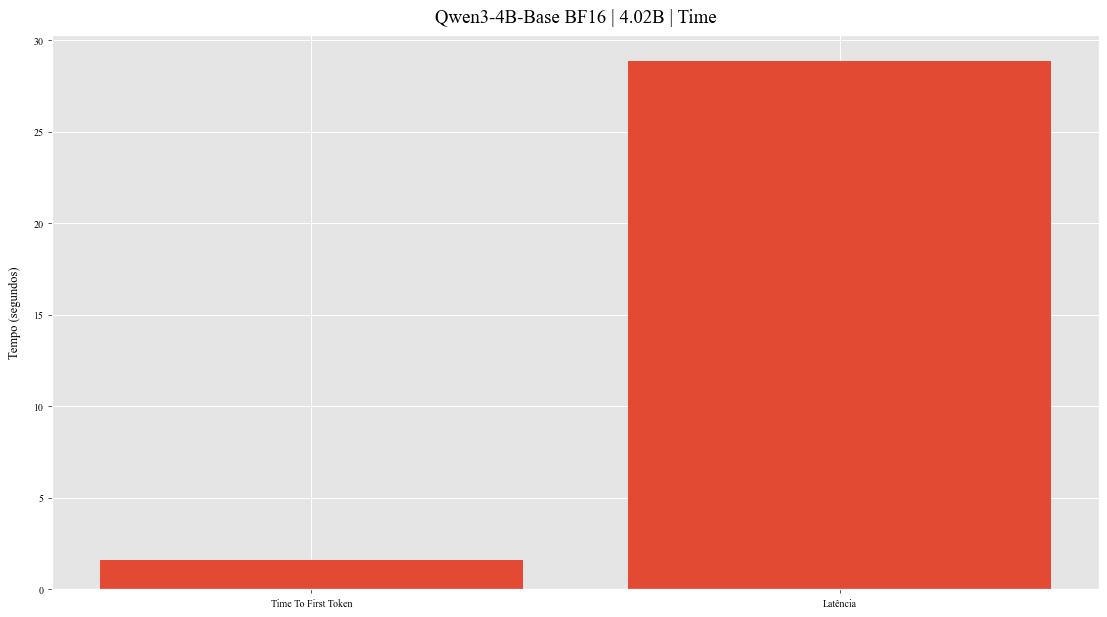

In [57]:
plt.figure (figsize = (15, 8), dpi = 90)
plt.style.use ("ggplot")
plt.bar (["Time To First Token", "Latência"], [sum(TtFT_CPU) / len(TtFT_CPU), sum(Lat_CPU) / len(Lat_CPU)])

plt.xticks (size = 8, fontname = "Times New Roman", color = "black")

plt.yticks (list(range(0, 35, 5)), size = 8, fontname = "Times New Roman", color = "black")
plt.ylabel ("Tempo (segundos)", size = 10, fontname = "Times New Roman", labelpad = 10, color = "black")

plt.title ("Qwen3-4B-Base BF16 | 4.02B | Time", size = 15, pad = 10, fontname = "Times New Roman")

plt.show()

<h1> Hardware </h1> CONTINUAR

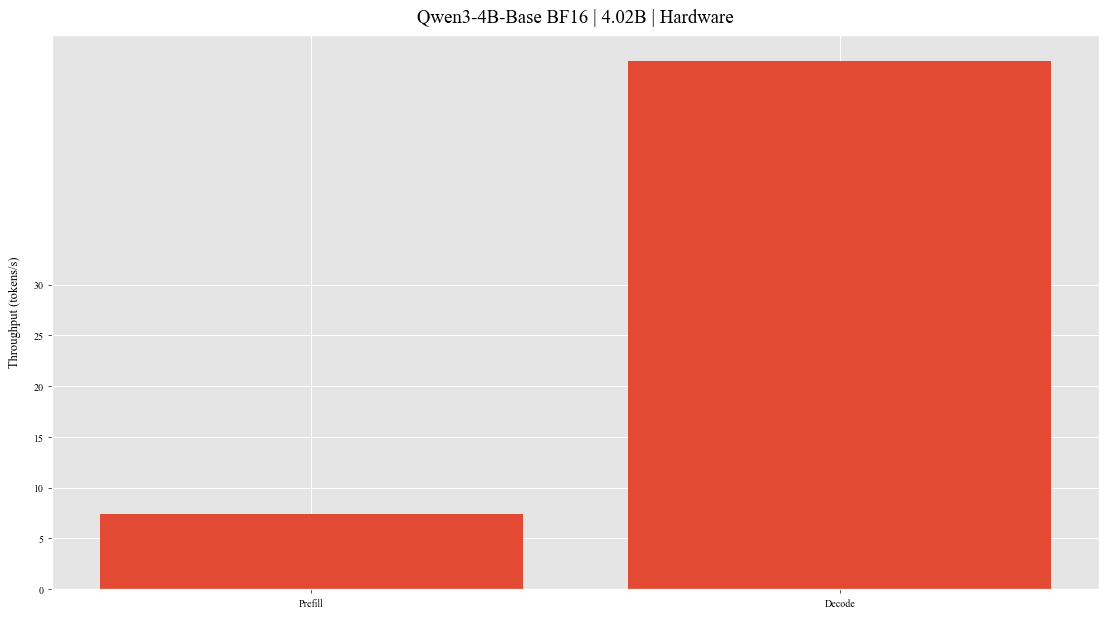

In [74]:
plt.figure (figsize = (15, 8), dpi = 90)
plt.style.use ("ggplot")
plt.bar (Throughput_CPU.keys(), [len(Throughput_CPU["Prefill"]) * 14 / sum(Throughput_CPU["Prefill"]), len(Throughput_CPU["Decode"]) * 1500 / sum(Lat_CPU)])

plt.xticks (size = 8, fontname = "Times New Roman", color = "black")

plt.yticks (list(range(0, 35, 5)), size = 8, fontname = "Times New Roman", color = "black")
plt.ylabel ("Throughput (tokens/s)", size = 10, fontname = "Times New Roman", labelpad = 10, color = "black")

plt.title ("Qwen3-4B-Base BF16 | 4.02B | Hardware", size = 15, pad = 10, fontname = "Times New Roman")

plt.show()

<h1> Memória </h1>

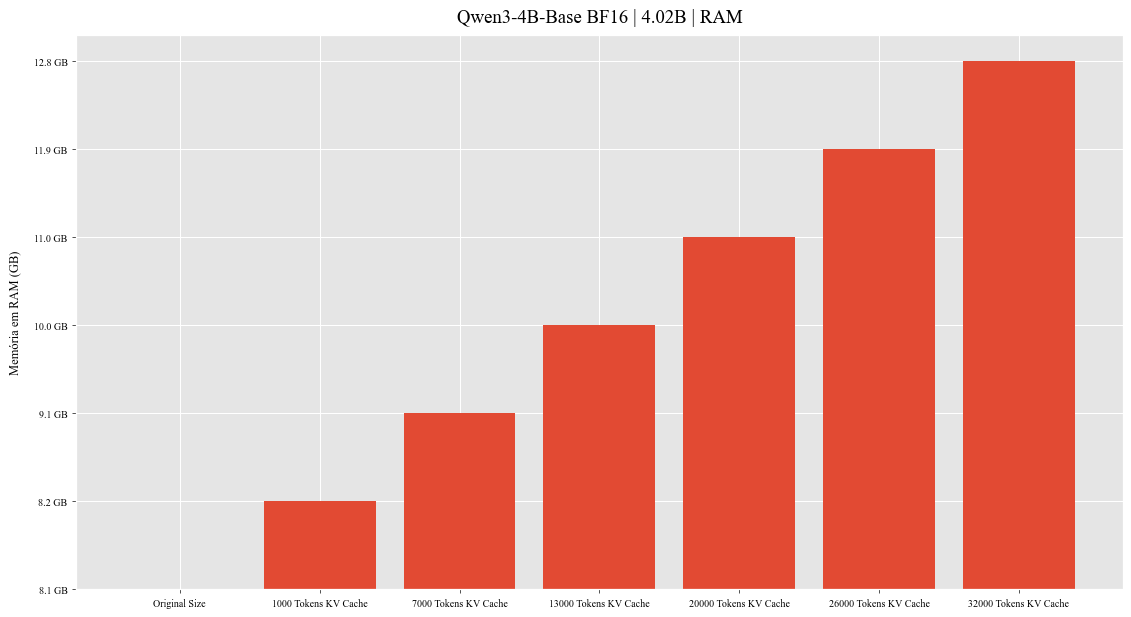

In [73]:
plt.figure (figsize = (15, 8), dpi = 90)
plt.style.use ("ggplot")

plt.bar (["Original Size", "1000 Tokens KV Cache", "7000 Tokens KV Cache", "13000 Tokens KV Cache", "20000 Tokens KV Cache", "26000 Tokens KV Cache", "32000 Tokens KV Cache"], QwenKV.values())

plt.yticks (size = 8, fontname = "Times New Roman", color = "black")
plt.ylabel ("Memória em RAM (GB)", size = 10, fontname = "Times New Roman", color = "black", labelpad = 10)

plt.xticks (size = 8,  fontname = "Times New Roman", color = "black")

plt.title ("Qwen3-4B-Base BF16 | 4.02B | RAM", size = 15, pad = 10, fontname = "Times New Roman")
plt.show()